<a href="https://colab.research.google.com/github/FransHutagalung/AnomaliUdara/blob/main/Project_Final_Bootcamp_Imilkom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Final Project


### Deskripsi Project



---

## 📌  Deteksi Anomali Kualitas Udara Berbasis IoT dengan Isolation Forest

Proyek ini merupakan implementasi sistem deteksi anomali pada data kualitas udara yang dikumpulkan dari **perangkat IoT buatan sendiri**. Sistem ini dirancang untuk membantu proses **monitoring lingkungan** secara real-time dengan mendeteksi nilai-nilai sensor yang tidak normal atau menyimpang (anomali), yang dapat menjadi indikasi awal terhadap potensi masalah seperti kebakaran, kerusakan sistem ventilasi, atau pencemaran udara.

### 🔧 Komponen Proyek:

#### 1. **Sumber Data - IoT Sensor**
Perangkat IoT yang saya kembangkan secara mandiri digunakan untuk mengumpulkan data dari berbagai sensor lingkungan, yang meliputi:
- **Suhu ruangan**
- **Kelembapan udara**
- **Kadar karbonmonoksida (CO)**
- **Indeks kualitas udara (AQI)**

#### 2. **Preprocessing**
Data mentah dari sensor diproses dengan beberapa tahap penting:
- Pembersihan dari nilai ekstrem (outlier ekstrim)
- Standarisasi skala fitur menggunakan `StandardScaler`
- Reduksi dimensi menggunakan **Principal Component Analysis (PCA)** untuk memvisualisasikan distribusi data

#### 3. **Model Deteksi Anomali - Isolation Forest**
Saya menggunakan **algoritma Isolation Forest** dari `scikit-learn`, yang sangat efektif untuk mendeteksi anomali dalam dataset berdimensi tinggi. Model dilatih hanya dengan data normal untuk mempelajari pola distribusi yang wajar, lalu digunakan untuk:
- Memberikan skor anomali pada data baru
- Mengklasifikasikan data sebagai `normal (1)` atau `anomali (-1)`

#### 4. **Visualisasi**
Untuk membantu pemantauan dan interpretasi hasil, dibuat visualisasi distribusi data menggunakan hasil dari PCA, dengan label warna untuk anomali dan data normal.

#### 5. **Prediksi Input Baru**
Model ini juga memungkinkan pengguna untuk memasukkan data sensor secara manual (suhu, kelembapan, CO, kualitas udara) dan langsung mendapatkan hasil prediksi apakah nilai tersebut normal atau anomali.





### Instalasi Dependensi


In [195]:
!pip install gdown
!gdown --fuzzy "https://drive.google.com/file/d/1ulup6nCJthgsiVvhsOGUnGtmqM1nmmhQ/view?usp=drive_link"

Downloading...
From: https://drive.google.com/uc?id=1ulup6nCJthgsiVvhsOGUnGtmqM1nmmhQ
To: /content/kualitas_udara.csv
100% 16.1k/16.1k [00:00<00:00, 36.5MB/s]


In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from sklearn.inspection import permutation_importance
import umap

### Load Data

In [197]:
df = pd.read_csv('/content/kualitas_udara.csv')
df.head()

,id,suhu,kelembaban,karbonmonoksida,kualitasudara,status_alarm,waktu
0,10,34.2,49,2219,349,0,2025-05-01 10:10:39
1,11,34.2,48,2206,350,0,2025-05-01 10:11:09
2,12,34.7,48,2197,346,0,2025-05-01 10:11:39
3,13,34.7,48,2187,350,0,2025-05-01 10:12:09
4,14,34.7,48,2191,348,0,2025-05-01 10:12:39


### Data Cleaning

In [198]:
df.drop(columns=['id', 'waktu'], inplace=True)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   suhu             277 non-null    float64
 1   kelembaban       277 non-null    int64  
 2   karbonmonoksida  277 non-null    int64  
 3   kualitasudara    277 non-null    int64  
 4   status_alarm     277 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 10.9 KB


In [200]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
272,False
273,False
274,False
275,False


In [201]:
df.duplicated().sum()

np.int64(7)

In [202]:
df.drop_duplicates(inplace=True)

In [203]:
df.duplicated().sum()

np.int64(0)

In [204]:
df.isna().sum()

,0
suhu,0
kelembaban,0
karbonmonoksida,0
kualitasudara,0
status_alarm,0


In [205]:
df['suhu']

,suhu
0,34.2
1,34.2
2,34.7
3,34.7
4,34.7
...,...
272,35.2
273,35.2
274,35.2
275,35.2


### Visualisasi Data

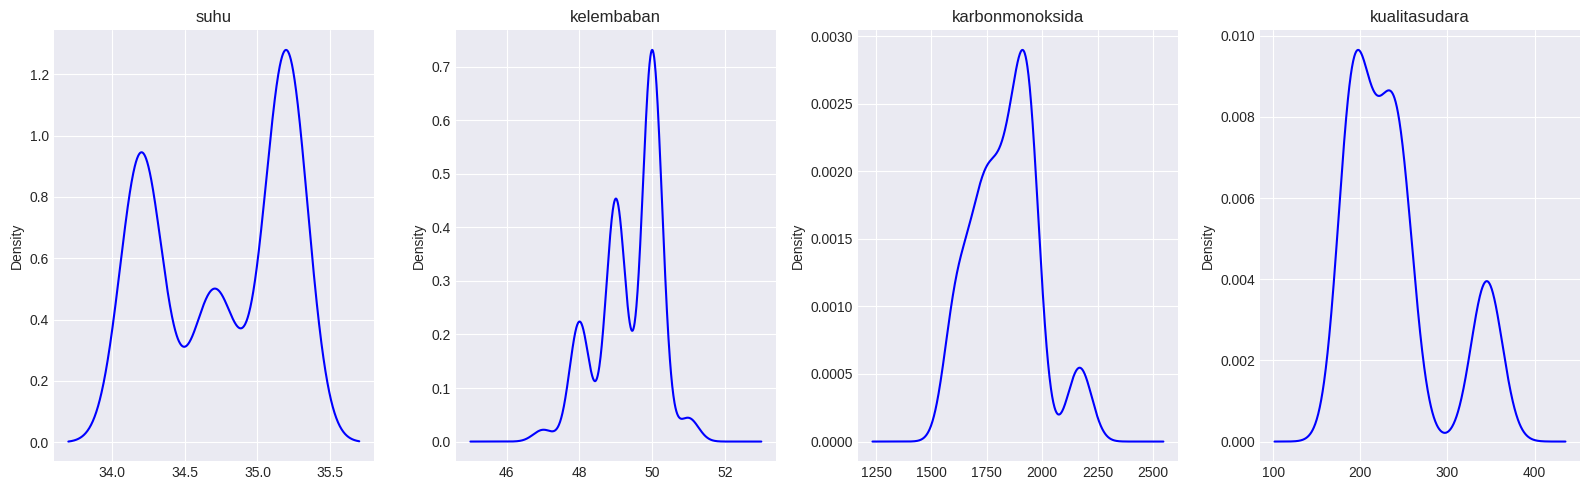

In [206]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 5))

for axes, column in zip(ax, columns):
    df[column].plot(kind='kde', ax=axes, color='blue', title=column)

plt.tight_layout()
plt.show()


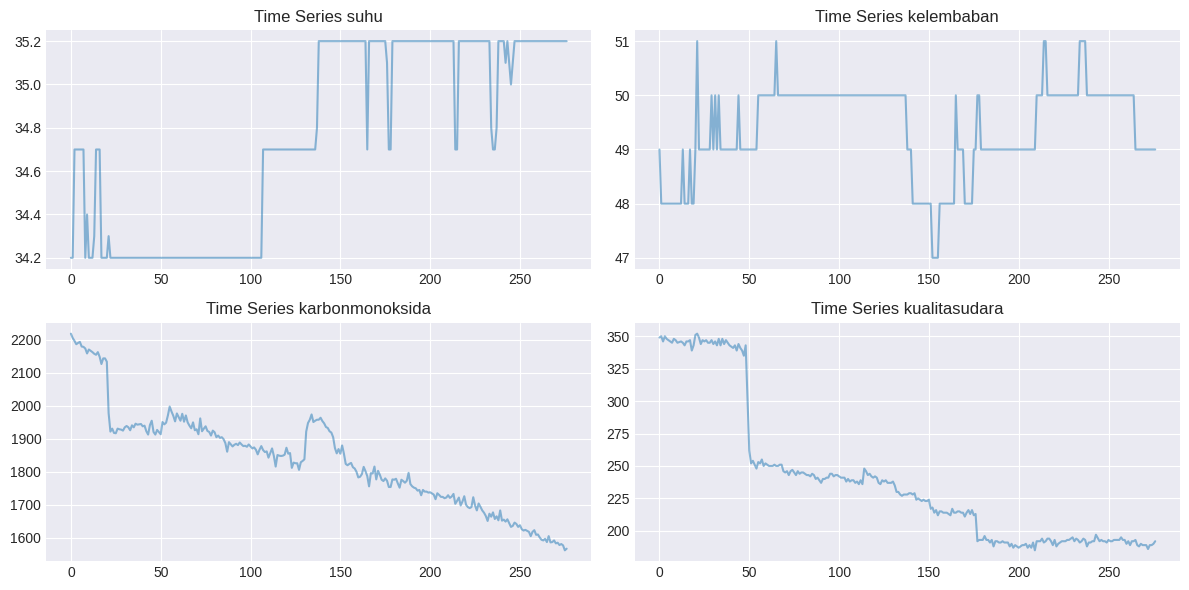

In [212]:
plt.figure(figsize=(12,6))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    plt.plot(df[col], alpha=0.5)
    plt.title(f'Time Series {col}')
plt.tight_layout()
plt.show()

In [211]:
fig = px.scatter_3d(df, x='suhu', y='kelembaban', z='karbonmonoksida',
                    color='kualitasudara', opacity=0.7,
                    title='3D Interactive Scatter Plot')
fig.show()


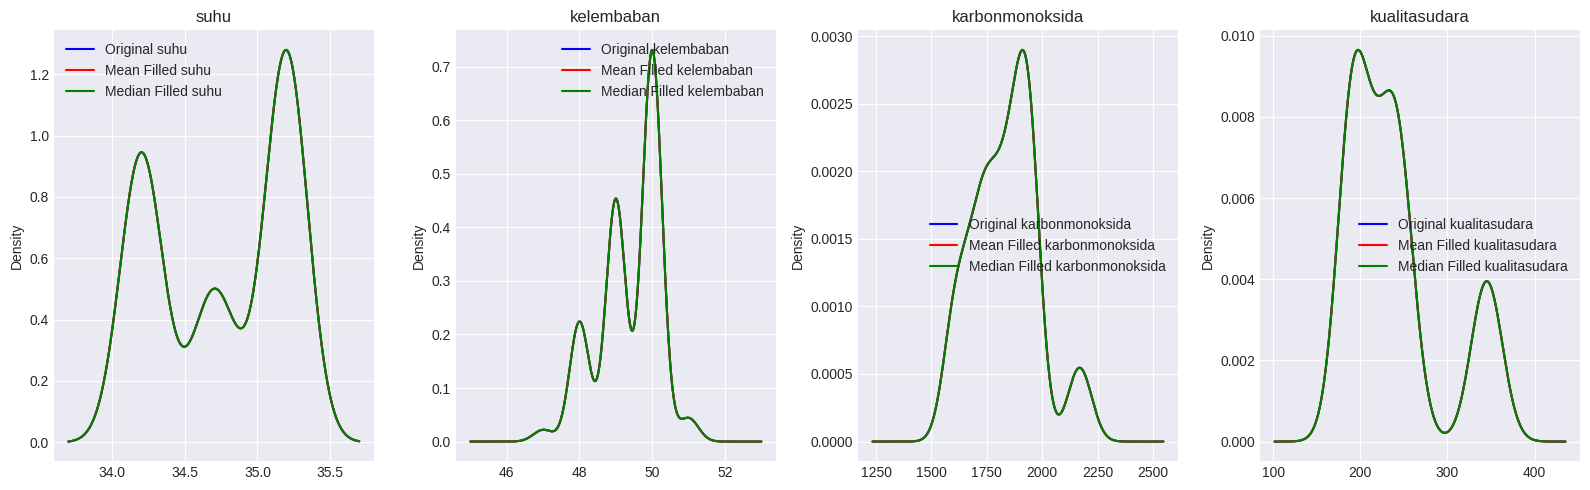

In [213]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))


for axes, column in zip(ax, df.columns):
  mean_filled = df[column].fillna(df[column].mean())
  median_filled = df[column].fillna(df[column].median())
  df.plot(kind='kde', y=column, ax=axes, color='blue', title=column, label=f'Original {column}')
  mean_filled.plot(kind='kde', y=column, ax=axes, color='red', label=f'Mean Filled {column}')
  median_filled.plot(kind='kde', y=column, ax=axes, color='green', label=f'Median Filled {column}')
  axes.legend()

plt.tight_layout()
plt.show()

In [214]:

for col in df.columns:
      df.loc[:, col] = df[col].fillna(df[col].median())


### Outlier

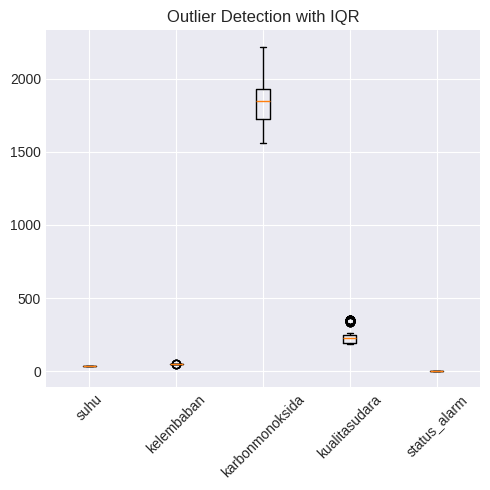

In [215]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

numeric_cols = [col for col in df.select_dtypes(include='number').columns ]

positions = range(len(numeric_cols))

for i, col in enumerate(numeric_cols):
    ax.boxplot(df[col].dropna(), positions=[positions[i]])

ax.set_xticks(positions)
ax.set_xticklabels(numeric_cols, rotation=45)

plt.title('Outlier Detection with IQR')
plt.tight_layout()
plt.show()


### Deteksi Outlier

In [216]:
def outlier_detection(data):
  IQR = np.quantile(data, 0.75) - np.quantile(data, 0.25)
  lower_bound = np.quantile(data, 0.25) - 1.5 * IQR
  upper_bound = np.quantile(data, 0.75) + 1.5 * IQR
  outliers = np.where((data < lower_bound) | (data > upper_bound), 1, 0)
  return outliers

In [217]:
for column in df.columns:
      df[column + '_outlier'] = outlier_detection(df[column])


In [218]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara,status_alarm,suhu_outlier,kelembaban_outlier,karbonmonoksida_outlier,kualitasudara_outlier,status_alarm_outlier
0,34.2,49,2219,349,0,0,0,0,1,0
1,34.2,48,2206,350,0,0,0,0,1,0
2,34.7,48,2197,346,0,0,0,0,1,0
3,34.7,48,2187,350,0,0,0,0,1,0
4,34.7,48,2191,348,0,0,0,0,1,0


In [219]:
for column in df.columns[-5:]:
  print(f"Outliers in {column}: {df[column].sum()}")

Outliers in suhu_outlier: 0
Outliers in kelembaban_outlier: 4
Outliers in karbonmonoksida_outlier: 0
Outliers in kualitasudara_outlier: 48
Outliers in status_alarm_outlier: 0


In [220]:
def drop_outliers(df):
    outlier_cols = df.columns[-3::]
    df_no_outliers = df[~(df[outlier_cols] == 1).any(axis=1)]
    return df_no_outliers

In [221]:
df_copy = df.copy()
df_copy = drop_outliers(df_copy)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 50 to 276
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   suhu                     222 non-null    float64
 1   kelembaban               222 non-null    int64  
 2   karbonmonoksida          222 non-null    int64  
 3   kualitasudara            222 non-null    int64  
 4   status_alarm             222 non-null    int64  
 5   suhu_outlier             222 non-null    int64  
 6   kelembaban_outlier       222 non-null    int64  
 7   karbonmonoksida_outlier  222 non-null    int64  
 8   kualitasudara_outlier    222 non-null    int64  
 9   status_alarm_outlier     222 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 19.1 KB


In [222]:
df.drop(columns=df.columns[-6::], inplace=True)

In [223]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara
0,34.2,49,2219,349
1,34.2,48,2206,350
2,34.7,48,2197,346
3,34.7,48,2187,350
4,34.7,48,2191,348


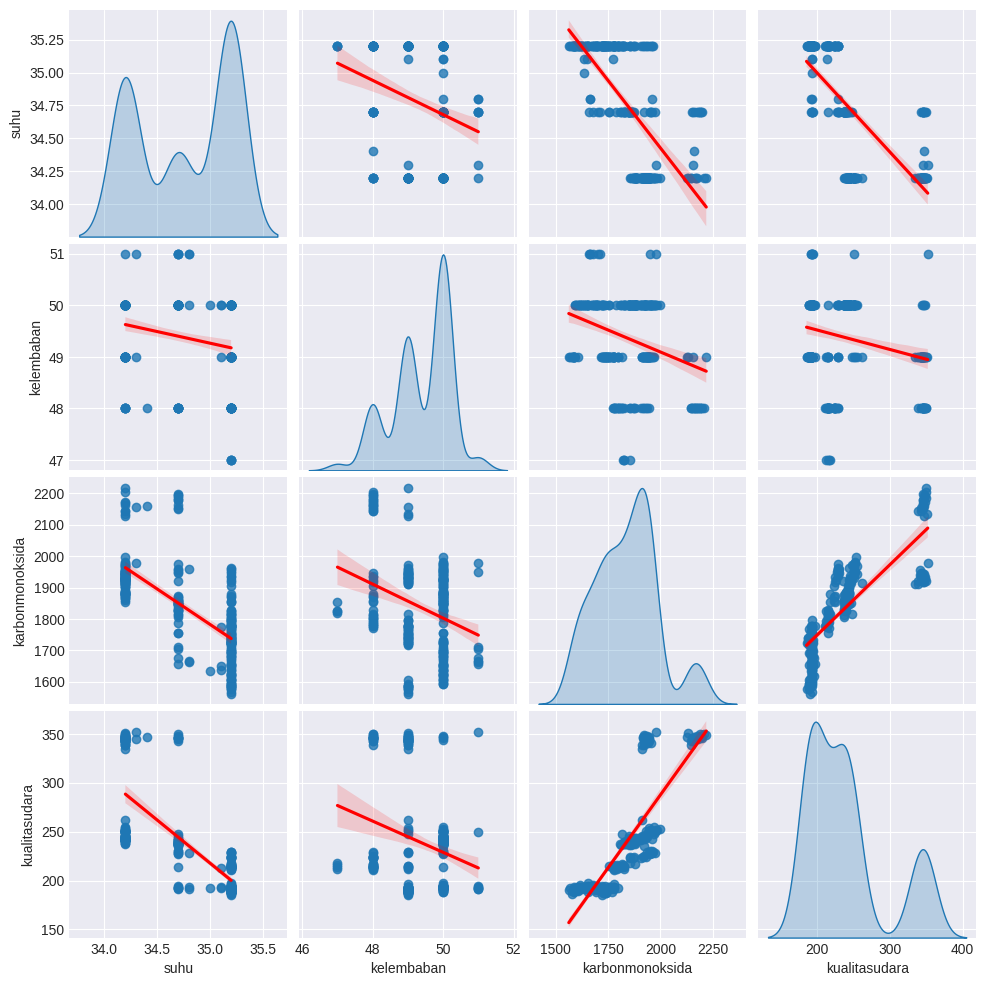

In [224]:
sns.pairplot(data=df, kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.show()

In [225]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara
0,34.2,49,2219,349
1,34.2,48,2206,350
2,34.7,48,2197,346
3,34.7,48,2187,350
4,34.7,48,2191,348


### Pearson

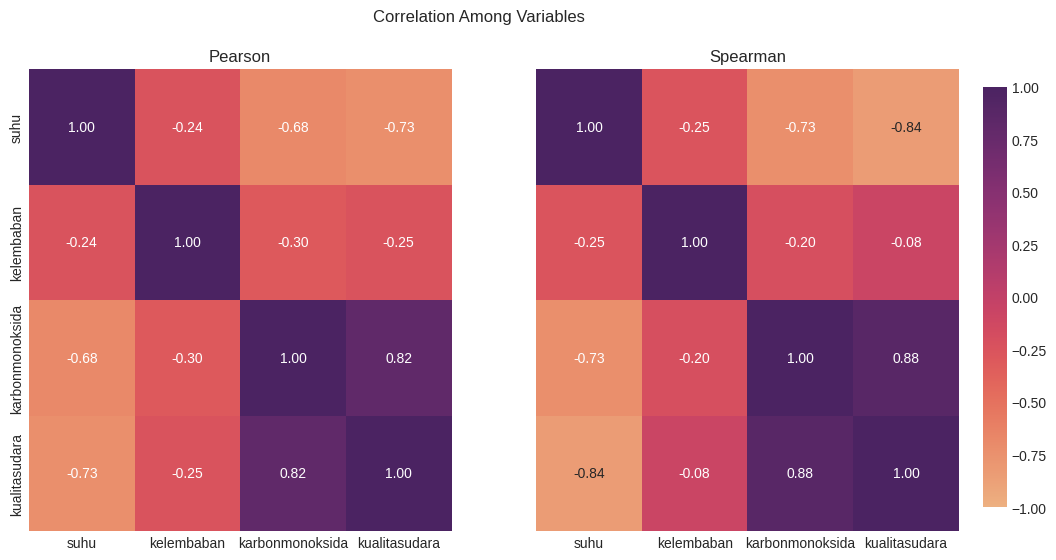

In [226]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
annot = True
fmt = '.2f'
cmap = 'flare'

sns.heatmap(df.corr(method='pearson'), annot=annot, vmin=-1, vmax=1, fmt=fmt, cmap=cmap, ax=ax[0], cbar=False)
sns.heatmap(df.corr(method='spearman'), annot=annot, vmin=-1, vmax=1, fmt=fmt, cmap=cmap, ax=ax[1], cbar=False)

ax[0].set_title('Pearson')
ax[1].set_title('Spearman')
fig.suptitle('Correlation Among Variables')
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust position and size as needed
fig.colorbar(ax[0].get_children()[0], cax=cbar_ax, orientation='vertical')

plt.show()

#### Split Data

In [227]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    df[df.columns[:]],
    df[df.columns[-1]],
    test_size=0.2
)

In [228]:
X_train

,suhu,kelembaban,karbonmonoksida,kualitasudara
45,34.2,49,1955,341
4,34.7,48,2191,348
105,34.2,50,1867,240
188,35.2,49,1797,192
196,35.2,49,1745,190
...,...,...,...,...
113,34.7,50,1848,236
116,34.7,50,1849,243
238,35.2,50,1653,188
92,34.2,50,1885,240


In [ ]:
X_test

,suhu,kelembaban,karbonmonoksida,kualitasudara
167,35.2,49,1796,215
80,34.2,50,1920,245
25,34.2,49,1917,346
187,35.2,49,1773,192
94,34.2,50,1889,241
213,35.2,50,1733,194
202,35.2,49,1731,189
188,35.2,49,1797,192
150,35.2,48,1855,224
214,34.7,51,1703,191


In [ ]:
Y_train

,kualitasudara
18,339
28,345
10,345
218,192
176,213
...,...
12,346
195,188
194,191
225,192


In [ ]:
Y_test

,kualitasudara
167,215
80,245
25,346
187,192
94,241
213,194
202,189
188,192
150,224
214,191


### Training Data

#### Feature Enginering

In [229]:
df['suhu_kelembaban'] = df['suhu'] * df['kelembaban']
df['co_ratio'] = df['karbonmonoksida'] / (df['kualitasudara'] + 1e-6)

Tanpa Feature Enginnering

In [ ]:
features = ['suhu', 'kelembaban', 'karbonmonoksida', 'kualitasudara']
X = df[features]

Dengan Feature Engineering


In [230]:
features = ['suhu', 'kelembaban', 'karbonmonoksida', 'kualitasudara',
            'suhu_kelembaban', 'co_ratio']
X = df[features]

Standard Scaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Robust Scaler

In [264]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Hyperparameter Tuning dengan GridSearchCV
params = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.7, 0.8, 0.9],
    'contamination': [0.01, 0.05, 0.1, 'auto']
}

model = IsolationForest(random_state=42, bootstrap=True)
grid_search = GridSearchCV(model, params, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_scaled)

# best_model = grid_search.best_estimator_
# print(f"Best Parameters: {grid_search.best_params_}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning:

One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]



GridSearchCV(cv=5, estimator=IsolationForest(bootstrap=True, random_state=42),
             n_jobs=-1,
             param_grid={'contamination': [0.01, 0.05, 0.1, 'auto'],
                         'max_samples': [0.7, 0.8, 0.9],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [265]:
model = IsolationForest(
    n_estimators=200,
    max_samples=0.9,
    contamination='auto',
    max_features=1.0,
    random_state=42
)
model.fit(X_scaled)

IsolationForest(max_samples=0.9, n_estimators=200, random_state=42)

In [188]:
predictions = model.predict(X_scaled)

In [266]:

predictions = model.fit_predict(X_scaled)

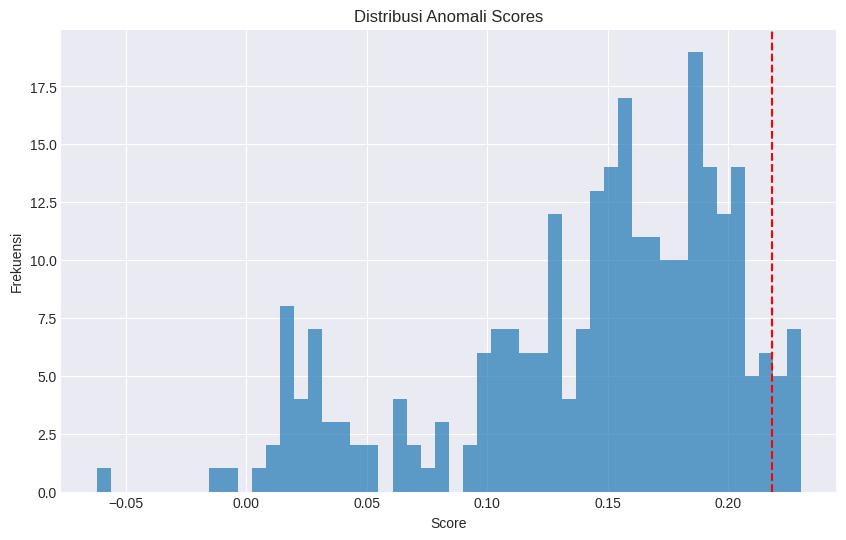

In [267]:
plt.figure(figsize=(10,6))
plt.hist(scores, bins=50, alpha=0.7)
plt.title('Distribusi Anomali Scores')
plt.xlabel('Score')
plt.ylabel('Frekuensi')
plt.axvline(np.percentile(scores, 95), color='r', linestyle='--')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



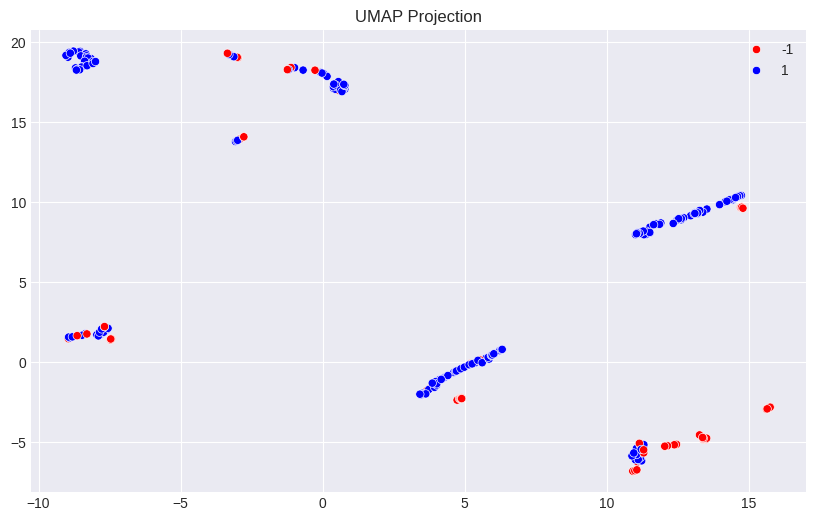

In [268]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1],
                hue=predictions, palette={1:'blue', -1:'red'})
plt.title('UMAP Projection')
plt.show()

In [269]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
                    color=predictions,
                    color_discrete_map={1:'blue', -1:'red'},
                    title='3D PCA Visualization')
fig.show()

### FIT Model

In [270]:
predictions = model.fit_predict(X_scaled)

In [271]:
X_result = pd.DataFrame(X_scaled, columns=features)
X_result['prediction'] = predictions

In [272]:
X_result

,suhu,kelembaban,karbonmonoksida,kualitasudara,suhu_kelembaban,co_ratio,prediction
0,-0.5,-1.0,1.806610,2.180180,-1.079295,-2.235398,-1
1,-0.5,-2.0,1.742962,2.198198,-1.832599,-2.299343,-1
2,0.0,-2.0,1.698898,2.126126,-1.303965,-2.245174,-1
3,0.0,-2.0,1.649939,2.198198,-1.303965,-2.362105,-1
4,0.0,-2.0,1.669523,2.162162,-1.303965,-2.307298,-1
...,...,...,...,...,...,...,...
265,0.5,-1.0,-1.331701,-0.756757,0.000000,0.222215,-1
266,0.5,-1.0,-1.317013,-0.702703,0.000000,0.084875,1
267,0.5,-1.0,-1.336597,-0.702703,0.000000,0.060407,1
268,0.5,-1.0,-1.410037,-0.684685,0.000000,-0.081640,-1


### PCA & Visualisasi

In [273]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_result['pca1'] = X_pca[:, 0]
X_result['pca2'] = X_pca[:, 1]

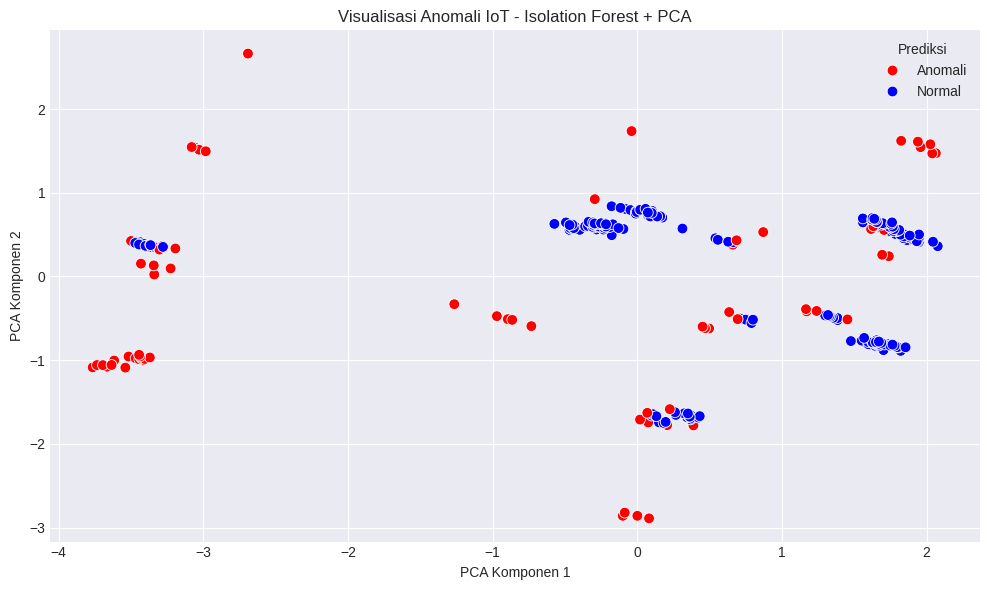

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

X_result['label'] = X_result['prediction'].map({1: 'Normal', -1: 'Anomali'})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='label',
    data=X_result,
    palette={'Normal': 'blue', 'Anomali': 'red'},
    s=60
)

plt.title("Visualisasi Anomali IoT - Isolation Forest + PCA")
plt.xlabel("PCA Komponen 1")
plt.ylabel("PCA Komponen 2")
plt.legend(title="Prediksi")
plt.grid(True)
plt.tight_layout()
plt.show()


In [275]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=['PCA Komponen 1', 'PCA Komponen 2'],
    index=features
)
print("\nKontribusi fitur terhadap PCA:")
print(loadings)


Kontribusi fitur terhadap PCA:
                 PCA Komponen 1  PCA Komponen 2
suhu                   0.181539       -0.217407
kelembaban             0.156539        0.831156
karbonmonoksida       -0.336700       -0.081163
kualitasudara         -0.540882        0.102556
suhu_kelembaban        0.316680        0.402593
co_ratio               0.660555       -0.287623


In [276]:
final_output = X.copy()
final_output['prediction'] = predictions
final_output.to_csv("hasil_deteksi_anomali.csv", index=False)
print("\nHasil deteksi disimpan ke 'hasil_deteksi_anomali.csv'")


Hasil deteksi disimpan ke 'hasil_deteksi_anomali.csv'


### Test data

In [280]:
input_data = pd.DataFrame([{
    'suhu': 36.2,
    'kelembaban': 107,
    'karbonmonoksida': 	1926,
    'kualitasudara': 347 ,
    'suhu_kelembaban': 36.2 * 67,
    'co_ratio': 1926 / (347 + 1e-6)
}])

In [281]:
input_scaled = scaler.transform(input_data)


In [282]:
pred_label = model.predict(input_scaled)[0]
score = model.decision_function(input_scaled)[0]

In [283]:
if pred_label == -1:
    print("⚠️ Udara terdeteksi sebagai ANOMALI!")
else:
    print("✅ Udara ini NORMAL.")

print(f"Skor anomali: {score:.4f}")

⚠️ Udara terdeteksi sebagai ANOMALI!
Skor anomali: -0.1942


#### Prediksi Tiap Feature

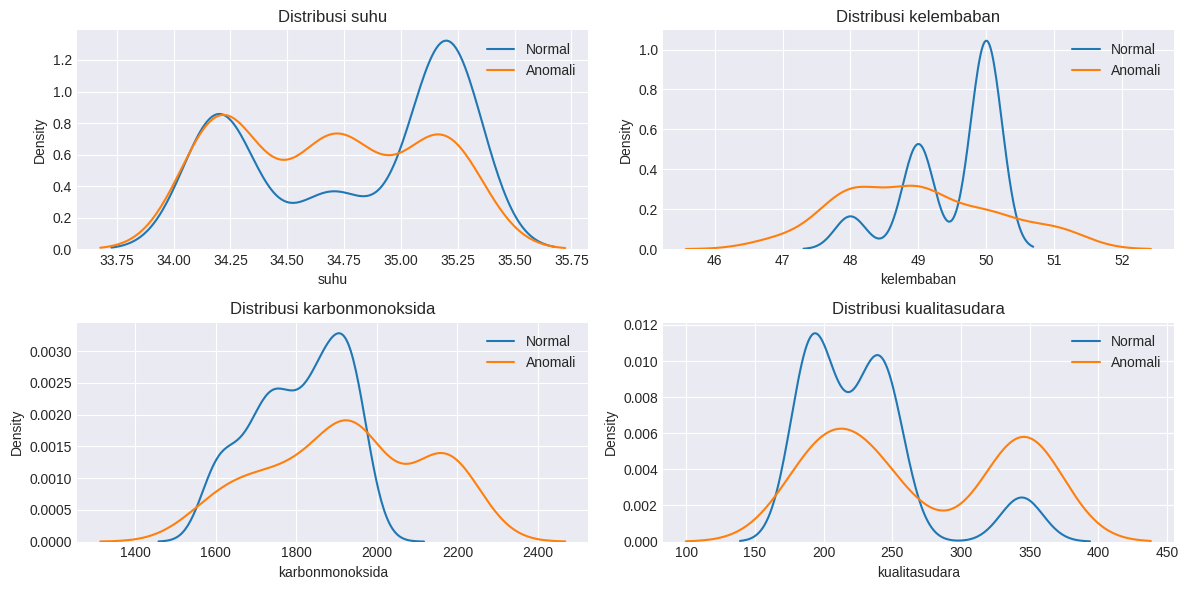

In [284]:
anomalies = df[predictions == -1]
normal = df[predictions == 1]

plt.figure(figsize=(12,6))
for i, col in enumerate(features[:4]):
    plt.subplot(2,2,i+1)
    sns.kdeplot(normal[col], label='Normal')
    sns.kdeplot(anomalies[col], label='Anomali')
    plt.title(f'Distribusi {col}')
    plt.legend()
plt.tight_layout()
plt.show()